## Agricultural Irrigation Analysis System

#### Load the irrigation data from a CSV file

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../datasets/dados_de_irrigacao.csv')

#### Visualize the data to understand the structure and available variables

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Horas de Irrigação        299 non-null    int64  
 1   Área Irrigada             299 non-null    int64  
 2   Área Irrigada por Ângulo  299 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 7.1 KB


In [7]:
df.head(10)

,Horas de Irrigação,Área Irrigada,Área Irrigada por Ângulo
0,1,100,66.666667
1,2,200,133.333333
2,3,300,200.000000
3,4,400,266.666667
4,5,500,333.333333
5,6,600,400.000000
6,7,700,466.666667
7,8,800,533.333333
8,9,900,600.000000
9,10,1000,666.666667


In [9]:
df.rename(columns={
    'Horas de Irrigação': 'Irrigation Hours',
    'Área Irrigada': 'Irrigated Area',
    'Área Irrigada por Ângulo':'Irrigated Area per Angle'
}, inplace=True)

In [10]:
df

,Irrigation Hours,Irrigated Area,Irrigated Area per Angle
0,1,100,66.666667
1,2,200,133.333333
2,3,300,200.000000
3,4,400,266.666667
4,5,500,333.333333
...,...,...,...
294,295,29500,19666.666667
295,296,29600,19733.333333
296,297,29700,19800.000000
297,298,29800,19866.666667


#### Calculate descriptive statistics of the variables

In [11]:
df.describe()

,Irrigation Hours,Irrigated Area,Irrigated Area per Angle
count,299.000000,299.000000,299.000000
mean,150.000000,15000.000000,10000.000000
std,86.458082,8645.808233,5763.872155
min,1.000000,100.000000,66.666667
25%,75.500000,7550.000000,5033.333333
50%,150.000000,15000.000000,10000.000000
75%,224.500000,22450.000000,14966.666667
max,299.000000,29900.000000,19933.333333


#### Create scatter plots to visualize the relationship between irrigation hours and irrigated area per angle

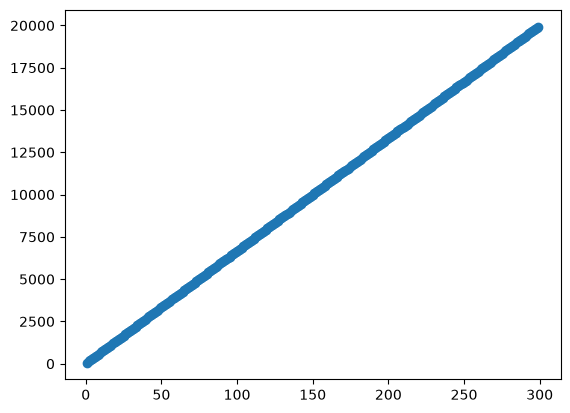

In [13]:
plt.scatter(df['Irrigation Hours'], df['Irrigated Area per Angle'])

In [17]:
# linear dispersion

#### Analyze the correlation between the variables

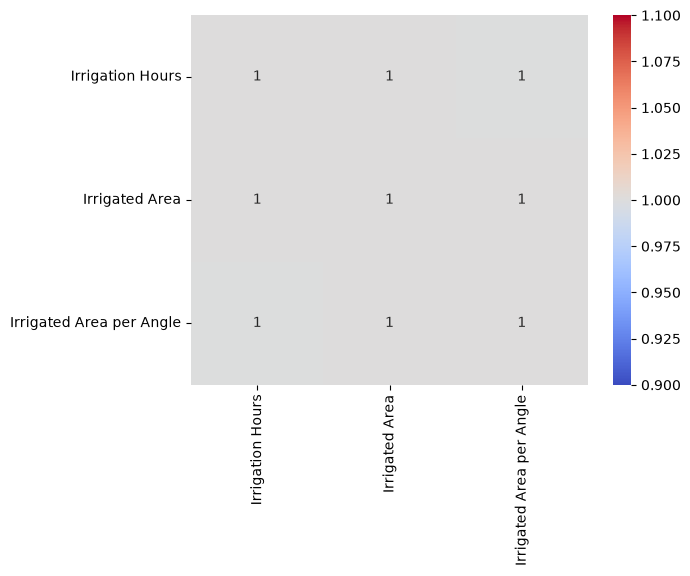

In [22]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.savefig('../images/heatmap_corr_variables.png', bbox_inches='tight', dpi=300)
plt.show()

#### Split the data into training and test sets

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [23]:
X = df[['Irrigation Hours']]
y = df['Irrigated Area per Angle']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Train a linear regression model using irrigation hours as the independent variable (X) and irrigated area per angle as the dependent variable (Y)

In [27]:
model = LinearRegression()

In [28]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[66.67]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Irrigation Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.819e-12
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


#### Print the equation of the line obtained by the model

In [32]:
print(f"Coefficient (coef_): {model.coef_[0]}")
print(f"Intercept (intercept_): {model.intercept_}")
print(f"Equation: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}")

Coefficient (coef_): 66.66666666666667
Intercept (intercept_): 1.8189894035458565e-12
Equation: y = 66.67x + 0.00


In [29]:
y_pred = model.predict(X_test)

#### Use performance metrics (MSE, MAE, and r2_score) to evaluate the model's accuracy

In [30]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 0.00
MSE: 0.00
R²: 1.00


#### Calculate and analyze the model's residuals

In [35]:
residuals = y_test - y_pred
print(residuals.describe())

count    6.000000e+01
mean    -2.559849e-12
std      1.313269e-12
min     -7.275958e-12
25%     -3.637979e-12
50%     -2.273737e-12
75%     -1.818989e-12
max      0.000000e+00
Name: Irrigated Area per Angle, dtype: float64


#### Visualize the actual vs predicted results in a chart

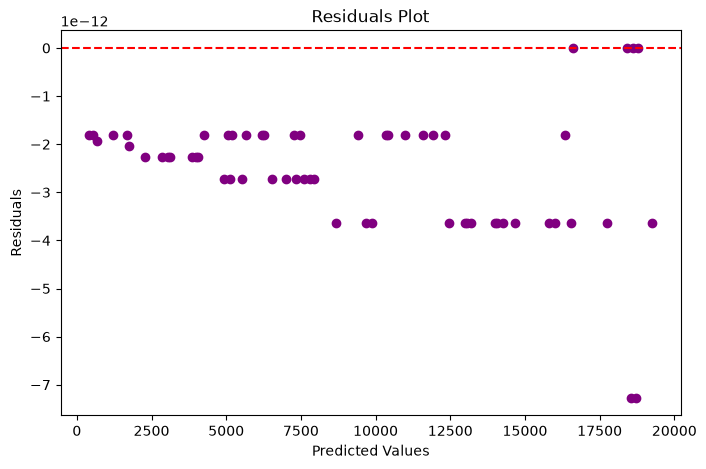

In [38]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.savefig('../images/residuals_plot.png', bbox_inches='tight', dpi=300)
plt.show()

#### Check the normality of the residuals using statistical tests and plots

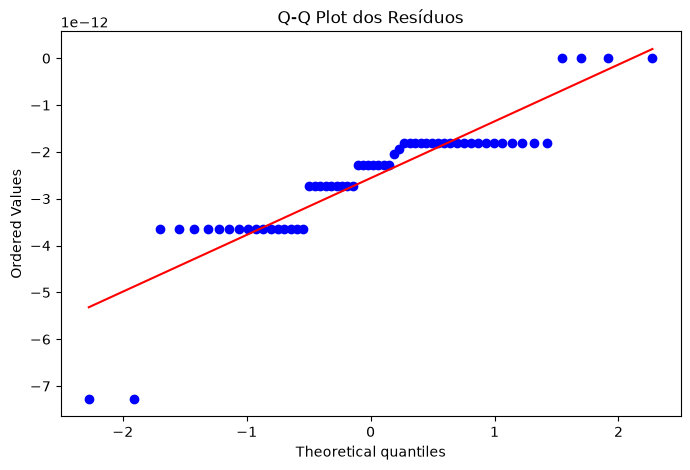

In [41]:
import scipy.stats as stats

plt.figure(figsize=(8,5))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot dos Resíduos')
plt.savefig('../images/qq_plot_residuals.png', bbox_inches='tight', dpi=300)
plt.show()

In [44]:
from scipy.stats import shapiro

stat, p_value = shapiro(residuals)
print(f"Statistic: {stat}, p-value: {p_value}")

Statistic: 0.8257789035494633, p-value: 6.304842767289157e-07


#### Use the model to make predictions (example: predict irrigated area per angle for 15 hours of irrigation)

In [45]:
hours = [[15]]
predict = model.predict(hours)
print(f"Forecast for 15 hours of irrigation: {predict[0]:.2f}")

Forecast for 15 hours of irrigation: 1000.00


c:\Users\grecc\.virtualenvs\ml-irrigation-analysis-X2oUOlHH\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
